In [1]:
!pip -q install seaborn scikit-learn imbalanced-learn joblib

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42

os.makedirs("charts", exist_ok=True)

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
df = sns.load_dataset("titanic")

print("Titanic dataset loaded successfully")

Titanic dataset loaded successfully


In [4]:
print("========== DATA INFO ==========")
df.info()

print("\n========== DESCRIBE ==========")
display(df.describe(include="all"))

print("\n========== SHAPE ==========")
print(df.shape)

========== DATA INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

========== DESCRIBE ==========


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



========== SHAPE ==========
(891, 15)


In [5]:
df.to_csv("titanic.csv", index=False)

print("titanic.csv saved successfully")

titanic.csv saved successfully


In [6]:
pd.read_csv("titanic.csv").head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [7]:
missing_percentage = (df.isnull().mean() * 100)

missing_percentage = (
    missing_percentage[missing_percentage > 0]
    .sort_values(ascending=False)
)

print("========== MISSING VALUES ==========")

for column, percentage in missing_percentage.items():
    print(f"{column}: {percentage:.2f}%")

========== MISSING VALUES ==========
deck: 77.22%
age: 19.87%
embarked: 0.22%
embark_town: 0.22%


In [8]:
print("========== MISSING VALUE DECISIONS ==========")

for column, percentage in missing_percentage.items():

    if percentage < 5:
        strategy = "Drop rows"

    elif percentage <= 30:
        strategy = "Impute"

    else:
        strategy = "Encode missing as separate category"

    print(
        f"{column}: {percentage:.2f}% missing -> {strategy}"
    )

========== MISSING VALUE DECISIONS ==========
deck: 77.22% missing -> Encode missing as separate category
age: 19.87% missing -> Impute
embarked: 0.22% missing -> Drop rows
embark_town: 0.22% missing -> Drop rows


In [9]:
clean_df = df.copy()

# Columns with <5% missing -> drop rows
low_missing_columns = [
    column
    for column, percentage in missing_percentage.items()
    if percentage < 5
]

if low_missing_columns:
    clean_df = clean_df.dropna(
        subset=low_missing_columns
    )


# Columns with 5%-30% missing -> impute
medium_missing_columns = [
    column
    for column, percentage in missing_percentage.items()
    if 5 <= percentage <= 30
]

for column in medium_missing_columns:

    if pd.api.types.is_numeric_dtype(clean_df[column]):

        clean_df[column] = clean_df[column].fillna(
            clean_df[column].median()
        )

    else:

        mode_value = clean_df[column].mode()

        if len(mode_value) > 0:
            clean_df[column] = clean_df[column].fillna(
                mode_value.iloc[0]
            )


# Columns with >30% missing -> encode missing as category
high_missing_columns = [
    column
    for column, percentage in missing_percentage.items()
    if percentage > 30
]

for column in high_missing_columns:

    if isinstance(clean_df[column].dtype, pd.CategoricalDtype):

        if "Missing" not in clean_df[column].cat.categories:
            clean_df[column] = clean_df[column].cat.add_categories(
                ["Missing"]
            )

    clean_df[column] = clean_df[column].fillna("Missing")


print("Cleaning completed")
print("\nRemaining missing values:")

remaining_missing = clean_df.isnull().sum()

display(
    remaining_missing[
        remaining_missing > 0
    ]
)

Cleaning completed

Remaining missing values:


,0


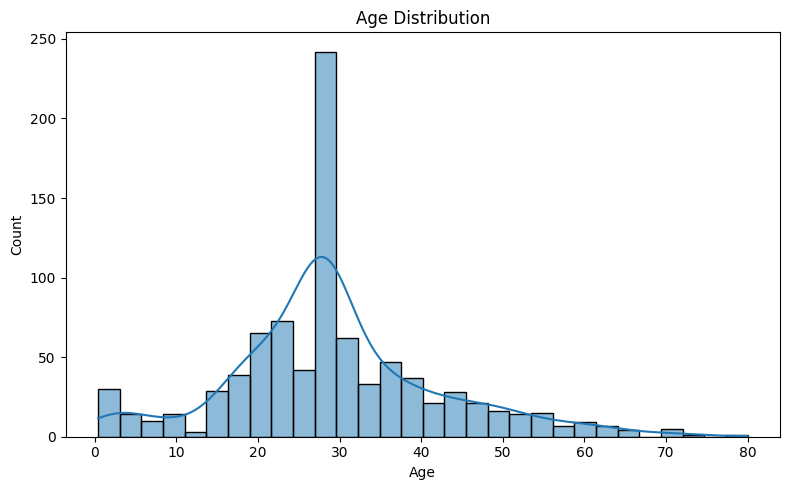

In [10]:
plt.figure(figsize=(8, 5))

sns.histplot(
    clean_df["age"].dropna(),
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("charts/age_histogram.png", dpi=150)

plt.show()

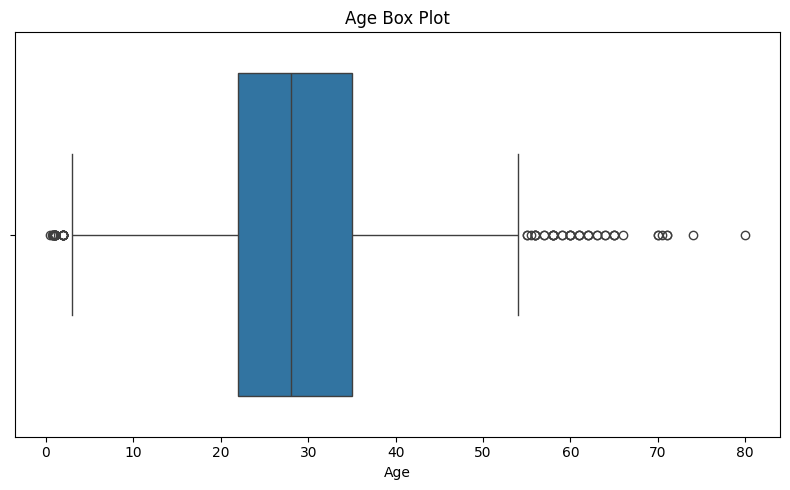

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=clean_df["age"].dropna()
)

plt.title("Age Box Plot")
plt.xlabel("Age")

plt.tight_layout()
plt.savefig("charts/age_boxplot.png", dpi=150)

plt.show()

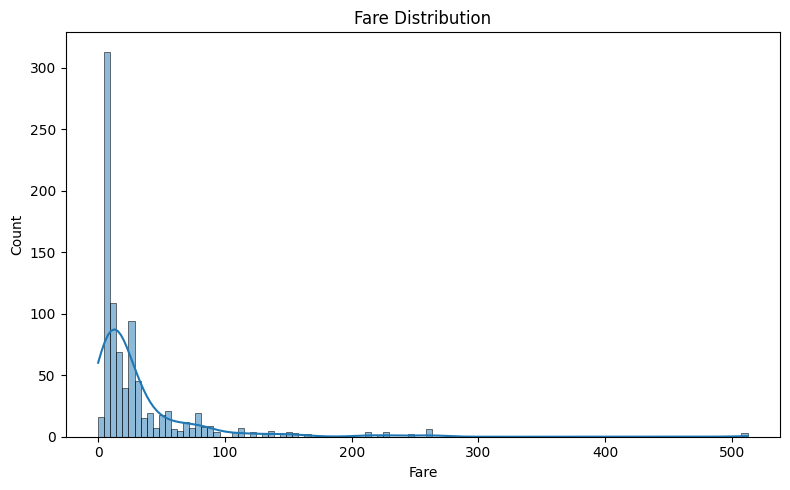

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(
    clean_df["fare"].dropna(),
    kde=True
)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("charts/fare_histogram.png", dpi=150)

plt.show()

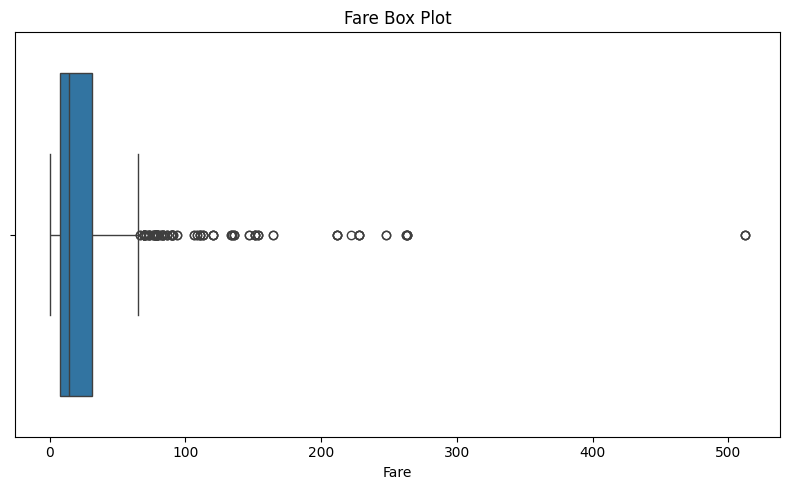

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x=clean_df["fare"].dropna()
)

plt.title("Fare Box Plot")
plt.xlabel("Fare")

plt.tight_layout()
plt.savefig("charts/fare_boxplot.png", dpi=150)

plt.show()

In [14]:
def calculate_iqr_outliers(series):

    series = series.dropna()

    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = series[
        (series < lower_limit) |
        (series > upper_limit)
    ]

    return (
        Q1,
        Q3,
        IQR,
        lower_limit,
        upper_limit,
        len(outliers)
    )


age_result = calculate_iqr_outliers(
    clean_df["age"]
)

fare_result = calculate_iqr_outliers(
    clean_df["fare"]
)

print("========== AGE OUTLIERS ==========")

print("Q1:", age_result[0])
print("Q3:", age_result[1])
print("IQR:", age_result[2])
print("Lower limit:", age_result[3])
print("Upper limit:", age_result[4])
print("Outlier count:", age_result[5])


print("\n========== FARE OUTLIERS ==========")

print("Q1:", fare_result[0])
print("Q3:", fare_result[1])
print("IQR:", fare_result[2])
print("Lower limit:", fare_result[3])
print("Upper limit:", fare_result[4])
print("Outlier count:", fare_result[5])

========== AGE OUTLIERS ==========
Q1: 22.0
Q3: 35.0
IQR: 13.0
Lower limit: 2.5
Upper limit: 54.5
Outlier count: 65

========== FARE OUTLIERS ==========
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower limit: -26.7605
Upper limit: 65.6563
Outlier count: 114


In [15]:
fare = clean_df["fare"].dropna()

fare_mean = fare.mean()
fare_median = fare.median()
fare_mode = fare.mode().iloc[0]

print("========== FARE STATISTICS ==========")

print(f"Mean   : {fare_mean:.4f}")
print(f"Median : {fare_median:.4f}")
print(f"Mode   : {fare_mode:.4f}")

========== FARE STATISTICS ==========
Mean   : 32.0967
Median : 14.4542
Mode   : 8.0500


In [16]:
if fare_mean > fare_median > fare_mode:

    conclusion = "Fare is right-skewed."

elif fare_mean < fare_median < fare_mode:

    conclusion = "Fare is left-skewed."

else:

    conclusion = (
        "Fare cannot be classified reliably using only "
        "the mean/median/mode ordering."
    )

print(conclusion)

print(
    f"\nMean = {fare_mean:.4f}, "
    f"Median = {fare_median:.4f}, "
    f"Mode = {fare_mode:.4f}"
)

Fare is right-skewed.

Mean = 32.0967, Median = 14.4542, Mode = 8.0500


In [17]:
survival_by_sex = (
    clean_df
    .groupby("sex", observed=True)["survived"]
    .mean()
)

print("========== SURVIVAL RATE BY SEX ==========")

display(
    (survival_by_sex * 100).round(2)
)

========== SURVIVAL RATE BY SEX ==========


,survived
sex,
female,74.04
male,18.89


In [18]:
survival_by_class = (
    clean_df
    .groupby("pclass", observed=True)["survived"]
    .mean()
)

print("========== SURVIVAL RATE BY PCLASS ==========")

display(
    (survival_by_class * 100).round(2)
)

========== SURVIVAL RATE BY PCLASS ==========


,survived
pclass,
1,62.62
2,47.28
3,24.24


In [19]:
survival_by_sex_class = (
    clean_df
    .groupby(
        ["sex", "pclass"],
        observed=True
    )["survived"]
    .mean()
)

print("========== SURVIVAL RATE BY SEX + PCLASS ==========")

display(
    (survival_by_sex_class * 100).round(2)
)

========== SURVIVAL RATE BY SEX + PCLASS ==========


sex     pclass
female  1         96.74
        2         92.11
        3         50.00
male    1         36.89
        2         15.74
        3         13.54
Name: survived, dtype: float64

In [20]:
female_first_second = clean_df[
    (clean_df["sex"] == "female") &
    (
        (clean_df["pclass"] == 1) |
        (clean_df["pclass"] == 2)
    )
]

male_third = clean_df[
    (clean_df["sex"] == "male") &
    (clean_df["pclass"] == 3)
]

print(
    "Female + First/Second Class Survival Rate:",
    round(
        female_first_second["survived"].mean() * 100,
        2
    ),
    "%"
)

print(
    "Male + Third Class Survival Rate:",
    round(
        male_third["survived"].mean() * 100,
        2
    ),
    "%"
)

Female + First/Second Class Survival Rate: 94.64 %
Male + Third Class Survival Rate: 13.54 %


In [21]:
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

correlation_matrix = clean_df[
    correlation_columns
].corr()

print("========== CORRELATION MATRIX ==========")

display(
    correlation_matrix.round(3)
)

========== CORRELATION MATRIX ==========


,survived,pclass,age,sibsp,parch,fare
survived,1.000,-0.336,-0.070,-0.034,0.083,0.255
pclass,-0.336,1.000,-0.337,0.082,0.017,-0.548
age,-0.070,-0.337,1.000,-0.233,-0.171,0.094
sibsp,-0.034,0.082,-0.233,1.000,0.415,0.161
parch,0.083,0.017,-0.171,0.415,1.000,0.218
fare,0.255,-0.548,0.094,0.161,0.218,1.000


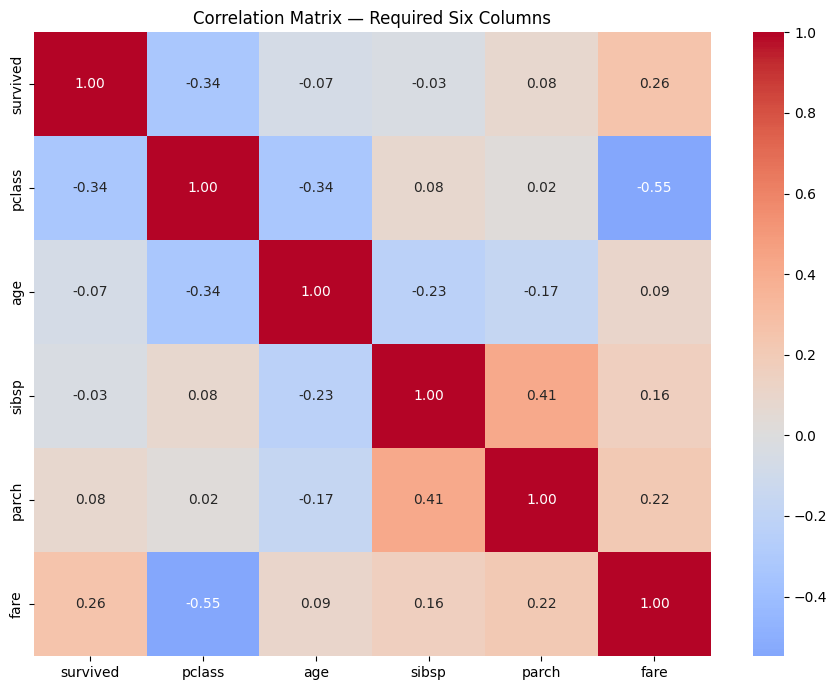

In [22]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix — Required Six Columns"
)

plt.tight_layout()

plt.savefig(
    "charts/correlation_heatmap.png",
    dpi=150
)

plt.show()

In [23]:
correlation_pairs = []

columns = correlation_matrix.columns

for i in range(len(columns)):

    for j in range(i + 1, len(columns)):

        value = correlation_matrix.iloc[i, j]

        correlation_pairs.append(
            (
                abs(value),
                value,
                columns[i],
                columns[j]
            )
        )


correlation_pairs.sort(
    reverse=True
)

print("========== TWO STRONGEST CORRELATIONS ==========")

for rank, pair in enumerate(
    correlation_pairs[:2],
    start=1
):

    absolute_value, value, column1, column2 = pair

    print(
        f"{rank}. {column1} vs {column2}: "
        f"r = {value:.4f}, "
        f"|r| = {absolute_value:.4f}"
    )

========== TWO STRONGEST CORRELATIONS ==========
1. pclass vs fare: r = -0.5482, |r| = 0.5482
2. sibsp vs parch: r = 0.4145, |r| = 0.4145


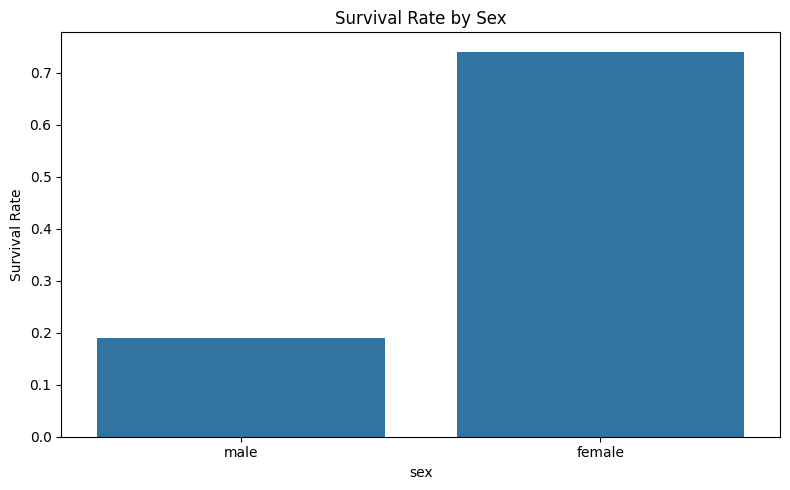

In [24]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=clean_df,
    x="sex",
    y="survived",
    errorbar=None
)

plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")

plt.tight_layout()

plt.savefig(
    "charts/01_survival_by_sex.png",
    dpi=150
)

plt.show()

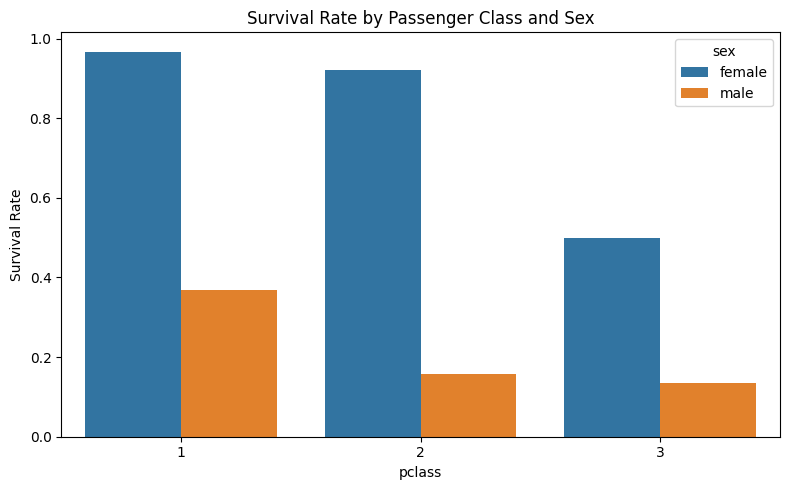

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=clean_df,
    x="pclass",
    y="survived",
    hue="sex",
    errorbar=None
)

plt.title(
    "Survival Rate by Passenger Class and Sex"
)

plt.ylabel("Survival Rate")

plt.tight_layout()

plt.savefig(
    "charts/02_survival_by_class_sex.png",
    dpi=150
)

plt.show()

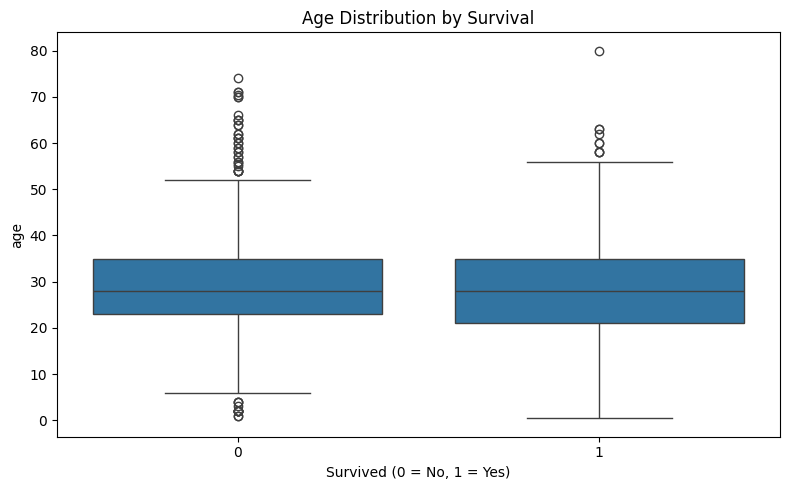

In [26]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=clean_df,
    x="survived",
    y="age"
)

plt.title(
    "Age Distribution by Survival"
)

plt.xlabel(
    "Survived (0 = No, 1 = Yes)"
)

plt.tight_layout()

plt.savefig(
    "charts/03_age_by_survival.png",
    dpi=150
)

plt.show()

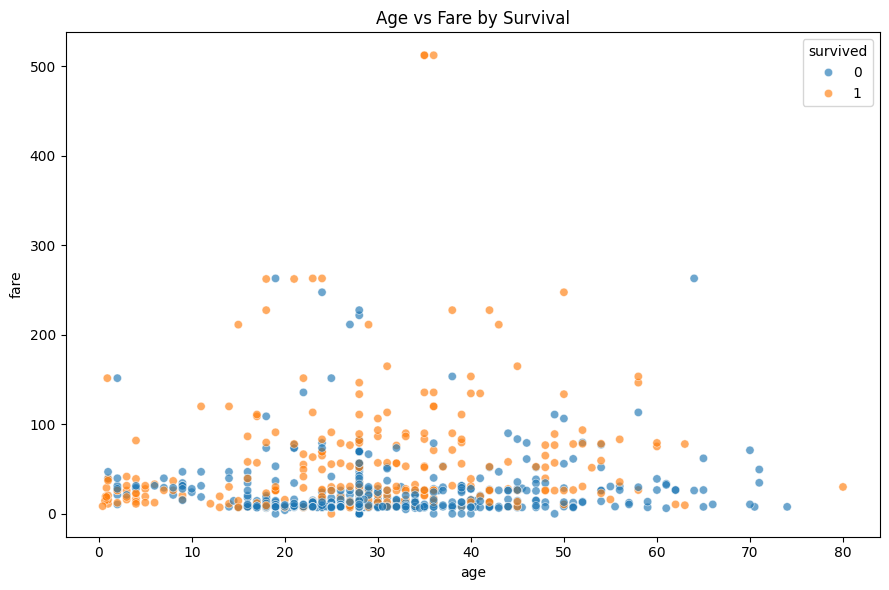

In [27]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=clean_df,
    x="age",
    y="fare",
    hue="survived",
    alpha=0.65
)

plt.title(
    "Age vs Fare by Survival"
)

plt.tight_layout()

plt.savefig(
    "charts/04_age_fare_survival.png",
    dpi=150
)

plt.show()

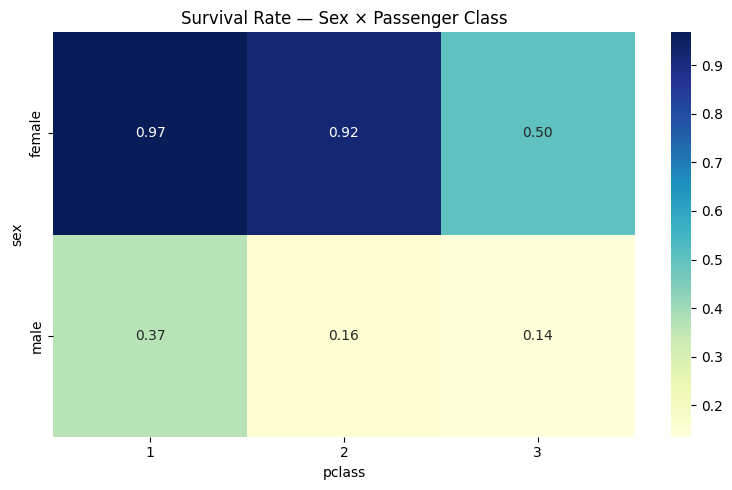

In [28]:
survival_pivot = clean_df.pivot_table(
    index="sex",
    columns="pclass",
    values="survived",
    aggfunc="mean"
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    survival_pivot,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title(
    "Survival Rate — Sex × Passenger Class"
)

plt.tight_layout()

plt.savefig(
    "charts/05_survival_sex_class_heatmap.png",
    dpi=150
)

plt.show()

In [29]:
standardization_df = clean_df[
    ["age", "fare"]
].copy()

print("========== BEFORE STANDARDIZATION ==========")

display(
    standardization_df.agg(
        ["mean", "std"]
    )
)

========== BEFORE STANDARDIZATION ==========


,age,fare
mean,29.315152,32.096681
std,12.984932,49.697504


In [30]:
standardized_df = standardization_df.copy()

for column in ["age", "fare"]:

    standardized_df[column] = (
        standardized_df[column]
        - standardized_df[column].mean()
    ) / standardized_df[column].std()

In [31]:
print("========== AFTER STANDARDIZATION ==========")

display(
    standardized_df.agg(
        ["mean", "std"]
    )
)

========== AFTER STANDARDIZATION ==========


,age,fare
mean,2.837375e-16,1.318780e-16
std,1.000000e+00,1.000000e+00


In [32]:
target = "survived"

feature_columns = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked",
    "class",
    "who",
    "adult_male",
    "deck",
    "embark_town",
    "alone"
]

X = clean_df[feature_columns].copy()

y = clean_df[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (889, 13)
y shape: (889,)


In [33]:
print("========== CLASS BALANCE ==========")

print(y.value_counts())

print("\nPercentage:")

display(
    (y.value_counts(normalize=True) * 100).round(2)
)

========== CLASS BALANCE ==========
survived
0    549
1    340
Name: count, dtype: int64

Percentage:


,proportion
survived,
0,61.75
1,38.25


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)

print("\nTraining class distribution:")
display(
    (y_train.value_counts(normalize=True) * 100).round(2)
)

print("\nTesting class distribution:")
display(
    (y_test.value_counts(normalize=True) * 100).round(2)
)

Training shape: (711, 13)
Testing shape : (178, 13)

Training class distribution:


,proportion
survived,
0,61.74
1,38.26



Testing class distribution:


,proportion
survived,
0,61.8
1,38.2


In [35]:
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked",
    "class",
    "who",
    "adult_male",
    "deck",
    "embark_town",
    "alone"
]

In [36]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created")

Preprocessing pipeline created


In [37]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )
}

print("Three classifiers created")

Three classifiers created


In [38]:
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    pipeline.fit(
        X_train,
        y_train
    )

    trained_models[name] = pipeline

    print(
        f"{name} trained successfully"
    )

Logistic Regression trained successfully
Decision Tree trained successfully
Random Forest trained successfully


In [39]:
results = {}

for name, pipeline in trained_models.items():

    y_pred = pipeline.predict(X_test)

    y_probability = pipeline.predict_proba(
        X_test
    )[:, 1]

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_test,
        y_probability
    )

    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    }

    print("\n================================")
    print(name)
    print("================================")

    print("\nConfusion Matrix:")
    print(cm)

    print(
        f"\nAccuracy : {accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f}"
    )

    print(
        f"Recall   : {recall:.4f}"
    )

    print(
        f"F1       : {f1:.4f}"
    )

    print(
        f"AUC      : {auc:.4f}"
    )


Logistic Regression

Confusion Matrix:
[[98 12]
 [17 51]]

Accuracy : 0.8371
Precision: 0.8095
Recall   : 0.7500
F1       : 0.7786
AUC      : 0.8693

Decision Tree

Confusion Matrix:
[[101   9]
 [ 28  40]]

Accuracy : 0.7921
Precision: 0.8163
Recall   : 0.5882
F1       : 0.6838
AUC      : 0.8352

Random Forest

Confusion Matrix:
[[94 16]
 [19 49]]

Accuracy : 0.8034
Precision: 0.7538
Recall   : 0.7206
F1       : 0.7368
AUC      : 0.8287


In [40]:
classifier_results = pd.DataFrame(
    results
).T

print("========== CLASSIFIER COMPARISON ==========")

display(
    classifier_results.round(4)
)

========== CLASSIFIER COMPARISON ==========


,Accuracy,Precision,Recall,F1,AUC
Logistic Regression,0.8371,0.8095,0.7500,0.7786,0.8693
Decision Tree,0.7921,0.8163,0.5882,0.6838,0.8352
Random Forest,0.8034,0.7538,0.7206,0.7368,0.8287


In [41]:
classifier_results.to_csv(
    "classifier_comparison.csv"
)

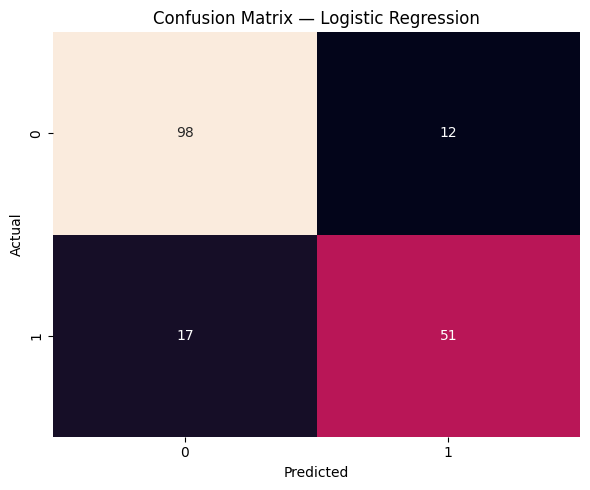

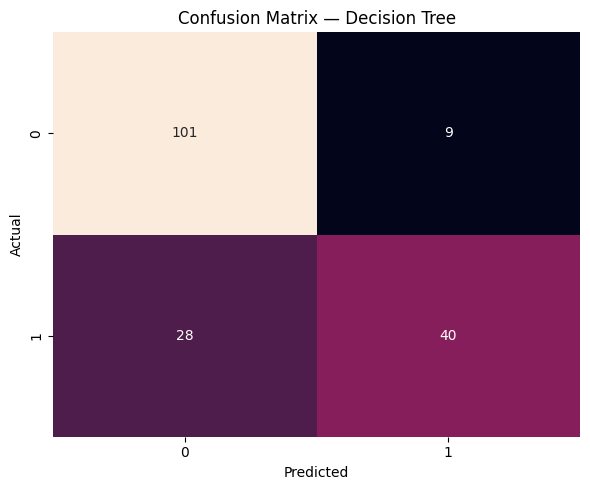

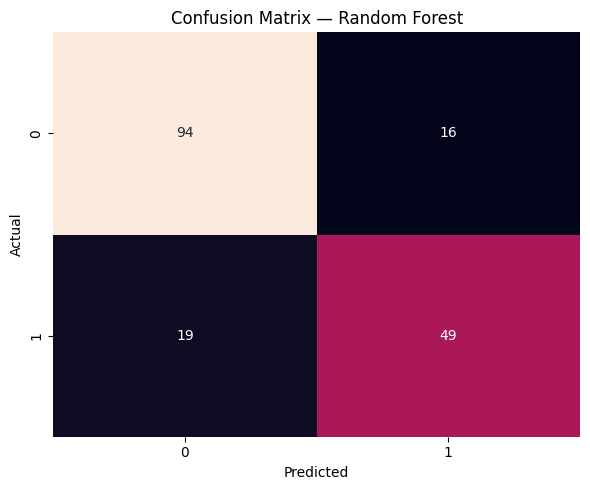

In [42]:
for name, pipeline in trained_models.items():

    predictions = pipeline.predict(
        X_test
    )

    cm = confusion_matrix(
        y_test,
        predictions
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cbar=False
    )

    plt.title(
        f"Confusion Matrix — {name}"
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()

    filename = (
        name.lower()
        .replace(" ", "_")
    )

    plt.savefig(
        f"charts/confusion_{filename}.png",
        dpi=150
    )

    plt.show()

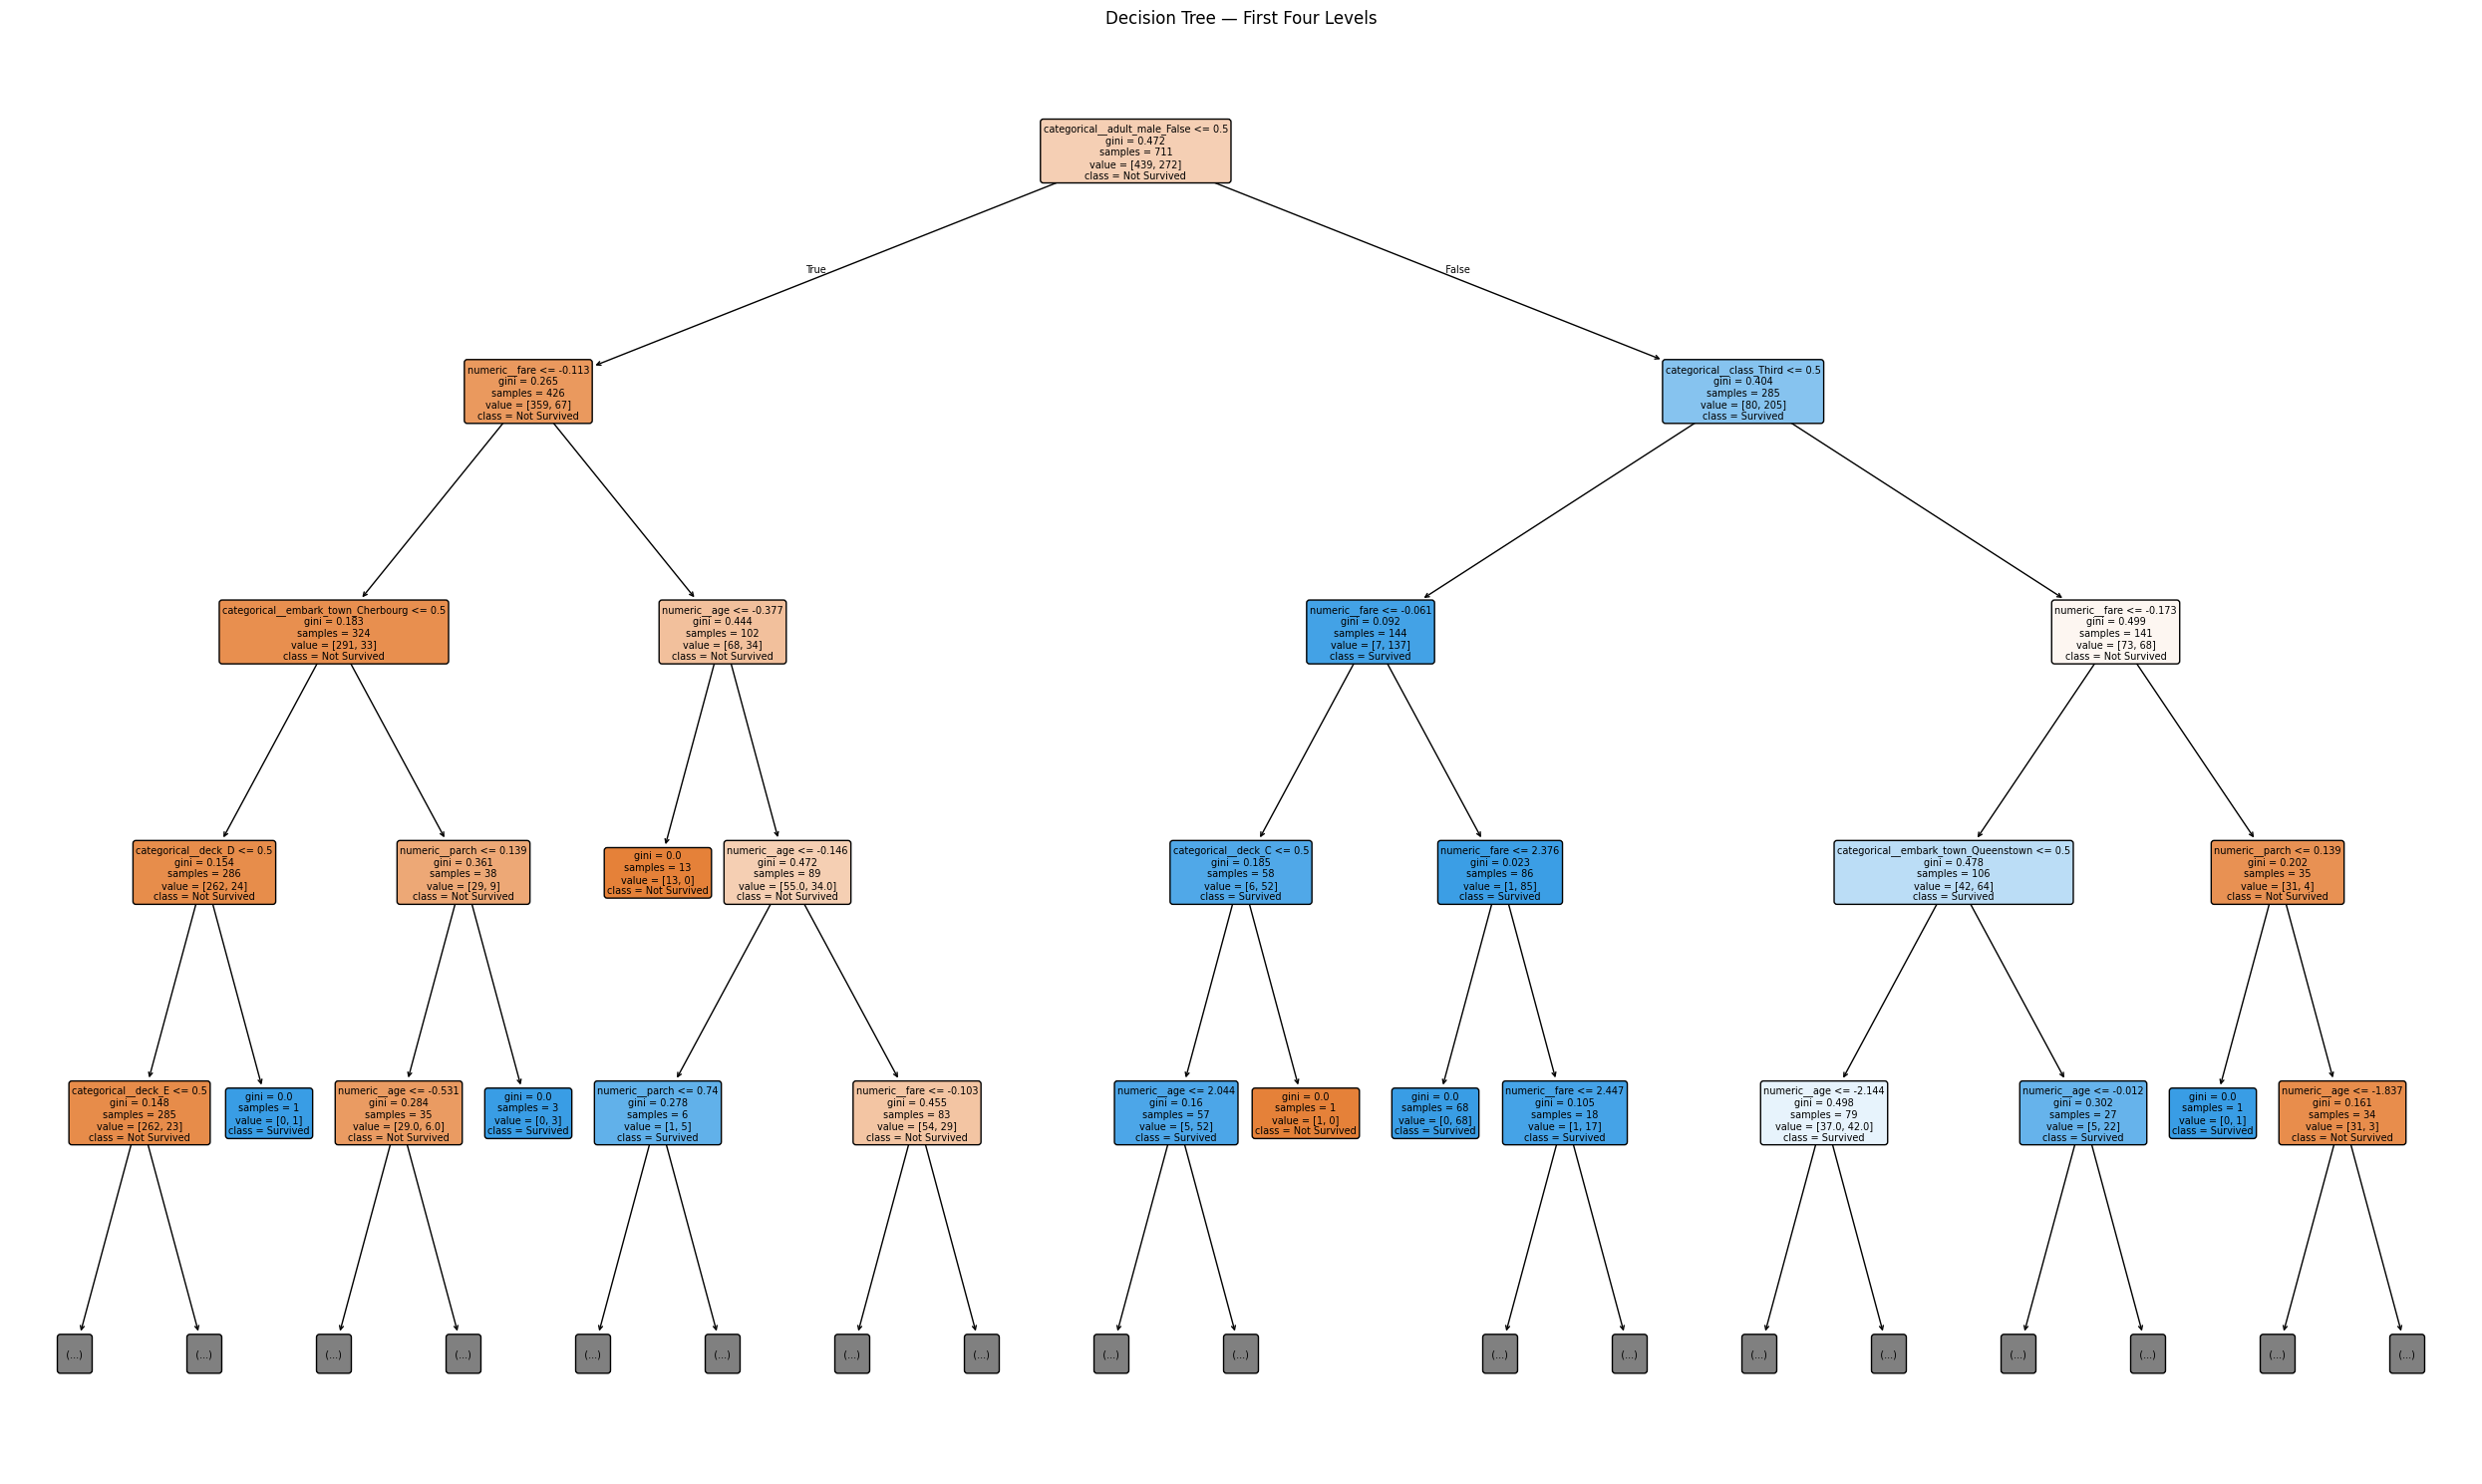

In [43]:
decision_tree_pipeline = trained_models[
    "Decision Tree"
]

decision_preprocessor = (
    decision_tree_pipeline
    .named_steps["preprocessor"]
)

decision_tree_model = (
    decision_tree_pipeline
    .named_steps["model"]
)

feature_names = (
    decision_preprocessor
    .get_feature_names_out()
)

plt.figure(figsize=(25, 15))

plot_tree(
    decision_tree_model,
    feature_names=feature_names,
    class_names=[
        "Not Survived",
        "Survived"
    ],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=7
)

plt.title(
    "Decision Tree — First Four Levels"
)

plt.tight_layout()

plt.savefig(
    "charts/decision_tree.png",
    dpi=180
)

plt.show()

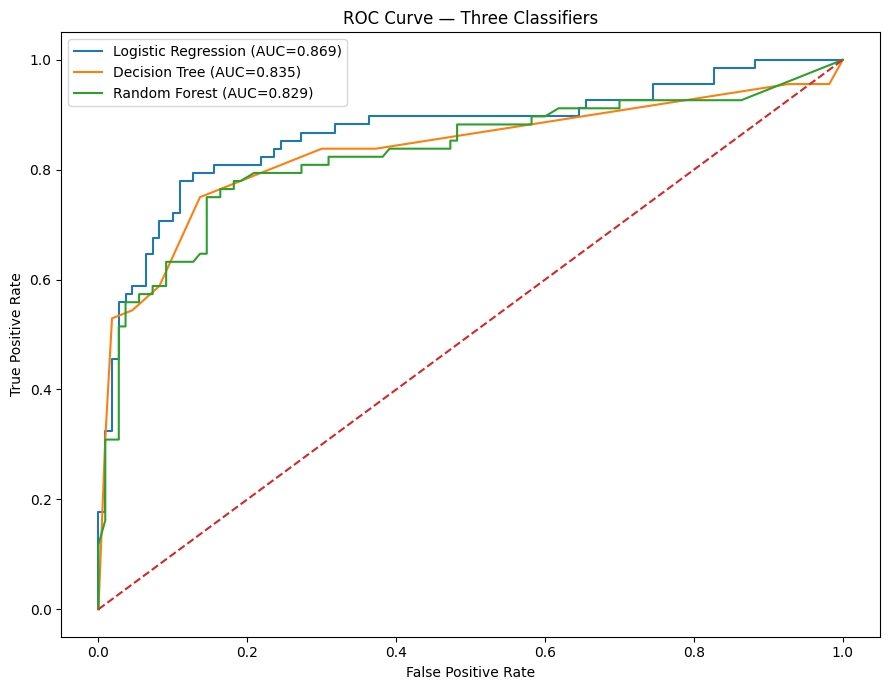

In [44]:
plt.figure(figsize=(9, 7))

for name, pipeline in trained_models.items():

    probabilities = pipeline.predict_proba(
        X_test
    )[:, 1]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        probabilities
    )

    auc = roc_auc_score(
        y_test,
        probabilities
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve — Three Classifiers"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "charts/roc_curves.png",
    dpi=150
)

plt.show()

In [45]:
baseline_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

baseline_pipeline.fit(
    X_train,
    y_train
)

baseline_prediction = baseline_pipeline.predict(
    X_test
)

baseline_metrics = {
    "Precision": precision_score(
        y_test,
        baseline_prediction,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        baseline_prediction,
        zero_division=0
    ),

    "F1": f1_score(
        y_test,
        baseline_prediction,
        zero_division=0
    )
}

print(baseline_metrics)

{'Precision': 0.7538461538461538, 'Recall': 0.7205882352941176, 'F1': 0.7368421052631579}


In [46]:
balanced_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

balanced_pipeline.fit(
    X_train,
    y_train
)

balanced_prediction = balanced_pipeline.predict(
    X_test
)

balanced_metrics = {
    "Precision": precision_score(
        y_test,
        balanced_prediction,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        balanced_prediction,
        zero_division=0
    ),

    "F1": f1_score(
        y_test,
        balanced_prediction,
        zero_division=0
    )
}

print(balanced_metrics)

{'Precision': 0.7538461538461538, 'Recall': 0.7205882352941176, 'F1': 0.7368421052631579}


In [47]:
smote_pipeline = ImbPipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "smote",
            SMOTE(
                random_state=42
            )
        ),

        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

smote_pipeline.fit(
    X_train,
    y_train
)

smote_prediction = smote_pipeline.predict(
    X_test
)

smote_metrics = {
    "Precision": precision_score(
        y_test,
        smote_prediction,
        zero_division=0
    ),

    "Recall": recall_score(
        y_test,
        smote_prediction,
        zero_division=0
    ),

    "F1": f1_score(
        y_test,
        smote_prediction,
        zero_division=0
    )
}

print(smote_metrics)

{'Precision': 0.7611940298507462, 'Recall': 0.75, 'F1': 0.7555555555555555}


In [48]:
imbalance_results = pd.DataFrame({

    "Baseline": baseline_metrics,

    "Class Weight Balanced": balanced_metrics,

    "SMOTE": smote_metrics

}).T

print(
    "========== IMBALANCE COMPARISON =========="
)

display(
    imbalance_results.round(4)
)

imbalance_results.to_csv(
    "imbalance_comparison.csv"
)

========== IMBALANCE COMPARISON ==========


,Precision,Recall,F1
Baseline,0.7538,0.7206,0.7368
Class Weight Balanced,0.7538,0.7206,0.7368
SMOTE,0.7612,0.7500,0.7556


In [49]:
best_imbalance_method = (
    imbalance_results["F1"]
    .idxmax()
)

best_imbalance_f1 = (
    imbalance_results.loc[
        best_imbalance_method,
        "F1"
    ]
)

print(
    f"Best imbalance strategy based on F1: "
    f"{best_imbalance_method}"
)

print(
    f"F1 score: {best_imbalance_f1:.4f}"
)

Best imbalance strategy based on F1: SMOTE
F1 score: 0.7556


In [50]:
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            RandomForestClassifier(
                random_state=42,
                oob_score=True
            )
        )
    ]
)


parameter_grid = {

    "model__n_estimators": [
        100,
        200
    ],

    "model__max_depth": [
        None,
        5,
        10
    ],

    "model__max_features": [
        "sqrt",
        "log2"
    ]
}


grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=parameter_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print(
    "Best Parameters:"
)

print(
    grid_search.best_params_
)

print(
    "\nBest CV F1:",
    grid_search.best_score_
)

Best Parameters:
{'model__max_depth': 5, 'model__max_features': 'log2', 'model__n_estimators': 100}

Best CV F1: 0.7470221803156536


In [51]:
best_rf_parameters = {
    key.replace(
        "model__",
        ""
    ): value
    for key, value
    in grid_search.best_params_.items()
}

best_rf = RandomForestClassifier(
    random_state=42,
    oob_score=True,
    **best_rf_parameters
)

best_rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            best_rf
        )
    ]
)

best_rf_pipeline.fit(
    X_train,
    y_train
)

oob_score = (
    best_rf_pipeline
    .named_steps["model"]
    .oob_score_
)

print(
    "Best Parameters:",
    grid_search.best_params_
)

print(
    "OOB Score:",
    round(oob_score, 4)
)

Best Parameters: {'model__max_depth': 5, 'model__max_features': 'log2', 'model__n_estimators': 100}
OOB Score: 0.8214


In [52]:
regression_target = "fare"

regression_features = [
    column
    for column in clean_df.columns
    if column not in [
        "fare",
        "survived"
    ]
]

regression_df = clean_df[
    regression_features +
    [regression_target]
].copy()

regression_df = regression_df.dropna(
    subset=["fare"]
)

X_reg = regression_df[
    regression_features
]

y_reg = regression_df[
    regression_target
]

print(
    "Regression X shape:",
    X_reg.shape
)

print(
    "Regression y shape:",
    y_reg.shape
)

Regression X shape: (889, 13)
Regression y shape: (889,)


In [53]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = (
    train_test_split(
        X_reg,
        y_reg,
        test_size=0.20,
        random_state=42
    )
)

print(
    X_reg_train.shape,
    X_reg_test.shape
)

(711, 13) (178, 13)


In [54]:
regression_numeric = (
    X_reg_train
    .select_dtypes(
        include=["number"]
    )
    .columns
    .tolist()
)

regression_categorical = (
    X_reg_train
    .select_dtypes(
        exclude=["number"]
    )
    .columns
    .tolist()
)

regression_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),

        (
            "scaler",
            StandardScaler()
        )
    ]
)

regression_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),

        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

regression_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            regression_numeric_pipeline,
            regression_numeric
        ),

        (
            "categorical",
            regression_categorical_pipeline,
            regression_categorical
        )
    ]
)

In [55]:
regression_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            regression_preprocessor
        ),

        (
            "model",
            LinearRegression()
        )
    ]
)

regression_pipeline.fit(
    X_reg_train,
    y_reg_train
)

regression_prediction = (
    regression_pipeline.predict(
        X_reg_test
    )
)

print(
    "Regression model trained successfully"
)

Regression model trained successfully


In [56]:
mae = mean_absolute_error(
    y_reg_test,
    regression_prediction
)

rmse = np.sqrt(
    mean_squared_error(
        y_reg_test,
        regression_prediction
    )
)

r2 = r2_score(
    y_reg_test,
    regression_prediction
)

transformed_X_test = (
    regression_pipeline
    .named_steps["preprocessor"]
    .transform(X_reg_test)
)

n = len(y_reg_test)

p = transformed_X_test.shape[1]

if n - p - 1 > 0:

    adjusted_r2 = (
        1 -
        (
            (1 - r2) *
            (n - 1) /
            (n - p - 1)
        )
    )

else:

    adjusted_r2 = np.nan


print("========== REGRESSION METRICS ==========")

print(
    f"MAE        : {mae:.4f}"
)

print(
    f"RMSE       : {rmse:.4f}"
)

print(
    f"R²         : {r2:.4f}"
)

print(
    f"Adjusted R²: {adjusted_r2:.4f}"
)

========== REGRESSION METRICS ==========
MAE        : 16.6924
RMSE       : 39.1215
R²         : 0.4263
Adjusted R²: 0.2997


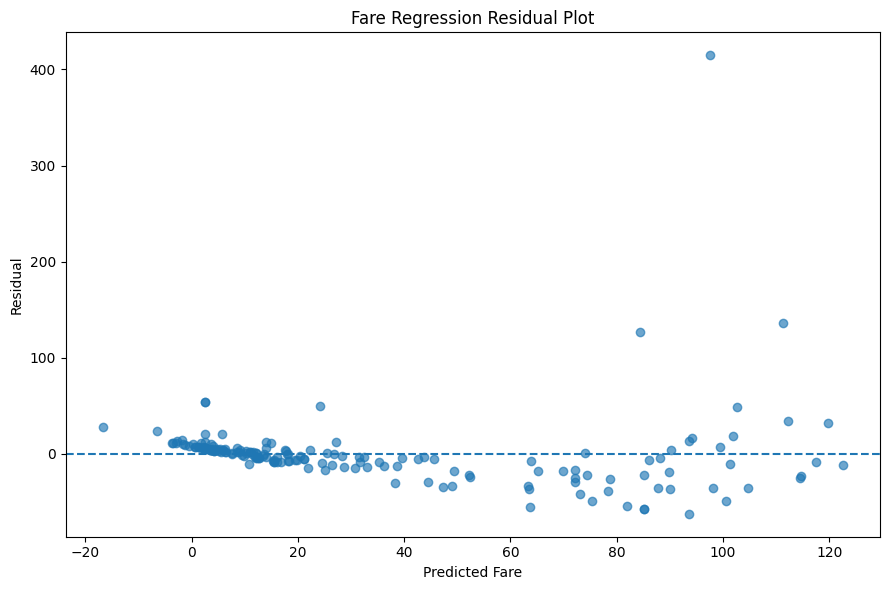

In [57]:
residuals = (
    y_reg_test -
    regression_prediction
)

plt.figure(figsize=(9, 6))

plt.scatter(
    regression_prediction,
    residuals,
    alpha=0.65
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Predicted Fare"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Fare Regression Residual Plot"
)

plt.tight_layout()

plt.savefig(
    "charts/regression_residuals.png",
    dpi=150
)

plt.show()

In [58]:
final_comparison = classifier_results.copy()

final_comparison[
    "MAE"
] = np.nan

final_comparison[
    "RMSE"
] = np.nan

final_comparison[
    "R2"
] = np.nan

final_comparison[
    "Adjusted R2"
] = np.nan


regression_row = pd.DataFrame(
    {
        "Accuracy": [np.nan],
        "Precision": [np.nan],
        "Recall": [np.nan],
        "F1": [np.nan],
        "AUC": [np.nan],
        "MAE": [mae],
        "RMSE": [rmse],
        "R2": [r2],
        "Adjusted R2": [adjusted_r2]
    },
    index=[
        "Linear Regression — Fare"
    ]
)


final_comparison = pd.concat(
    [
        final_comparison,
        regression_row
    ]
)


print(
    "========== FINAL MODEL COMPARISON =========="
)

display(
    final_comparison.round(4)
)

final_comparison.to_csv(
    "final_model_comparison.csv"
)

========== FINAL MODEL COMPARISON ==========


,Accuracy,Precision,Recall,F1,AUC,MAE,RMSE,R2,Adjusted R2
Logistic Regression,0.8371,0.8095,0.7500,0.7786,0.8693,NaN,NaN,NaN,NaN
Decision Tree,0.7921,0.8163,0.5882,0.6838,0.8352,NaN,NaN,NaN,NaN
Random Forest,0.8034,0.7538,0.7206,0.7368,0.8287,NaN,NaN,NaN,NaN
Linear Regression — Fare,NaN,NaN,NaN,NaN,NaN,16.6924,39.1215,0.4263,0.2997


In [59]:
best_classifier = (
    classifier_results["F1"]
    .idxmax()
)

best_accuracy = (
    classifier_results
    .loc[best_classifier, "Accuracy"]
)

best_precision = (
    classifier_results
    .loc[best_classifier, "Precision"]
)

best_recall = (
    classifier_results
    .loc[best_classifier, "Recall"]
)

best_f1 = (
    classifier_results
    .loc[best_classifier, "F1"]
)

best_auc = (
    classifier_results
    .loc[best_classifier, "AUC"]
)


print("========== FINAL RECOMMENDATION ==========")

print(
    f"I recommend {best_classifier} "
    f"for deployment."
)

print(
    f"Accuracy = {best_accuracy:.4f}"
)

print(
    f"Precision = {best_precision:.4f}"
)

print(
    f"Recall = {best_recall:.4f}"
)

print(
    f"F1 = {best_f1:.4f}"
)

print(
    f"AUC = {best_auc:.4f}"
)

========== FINAL RECOMMENDATION ==========
I recommend Logistic Regression for deployment.
Accuracy = 0.8371
Precision = 0.8095
Recall = 0.7500
F1 = 0.7786
AUC = 0.8693


In [60]:
final_estimators = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            random_state=42
        )
}


final_model = final_estimators[
    best_classifier
]


full_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            final_model
        )
    ]
)


full_pipeline.fit(
    X_train,
    y_train
)


joblib.dump(
    full_pipeline,
    "best_titanic_pipeline.joblib"
)

print(
    "Complete pipeline saved successfully."
)

Complete pipeline saved successfully.


In [61]:
loaded_pipeline = joblib.load(
    "best_titanic_pipeline.joblib"
)

raw_sample = X_test.iloc[[0]]

prediction = loaded_pipeline.predict(
    raw_sample
)

probability = (
    loaded_pipeline
    .predict_proba(raw_sample)
)

print("========== RELOADED PIPELINE TEST ==========")

print("\nRaw input:")
display(raw_sample)

print(
    "Prediction:",
    prediction[0]
)

print(
    "Survival probability:",
    round(
        probability[0][1],
        4
    )
)

========== RELOADED PIPELINE TEST ==========

Raw input:


,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
160,3,male,44.0,0,1,16.1,S,Third,man,True,Missing,Southampton,False


Prediction: 0
Survival probability: 0.0631


In [62]:
with open(
    "query_output.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(
        "MODULE 2 — ANALYTICS PIPELINE OUTPUT\n"
    )

    file.write(
        "=" * 60 + "\n\n"
    )

    file.write(
        f"Original shape: {df.shape}\n"
    )

    file.write(
        f"Cleaned shape: {clean_df.shape}\n\n"
    )

    file.write(
        "Missing value percentages:\n"
    )

    file.write(
        missing_percentage.to_string()
    )

    file.write("\n\n")

    file.write(
        "Age IQR outlier count: "
        f"{age_result[5]}\n"
    )

    file.write(
        "Fare IQR outlier count: "
        f"{fare_result[5]}\n\n"
    )

    file.write(
        "Fare statistics:\n"
    )

    file.write(
        f"Mean: {fare_mean:.4f}\n"
    )

    file.write(
        f"Median: {fare_median:.4f}\n"
    )

    file.write(
        f"Mode: {fare_mode:.4f}\n"
    )

    file.write(
        f"Skewness: {conclusion}\n\n"
    )

    file.write(
        "Survival by sex:\n"
    )

    file.write(
        (
            survival_by_sex * 100
        ).round(2).to_string()
    )

    file.write("\n\n")

    file.write(
        "Survival by pclass:\n"
    )

    file.write(
        (
            survival_by_class * 100
        ).round(2).to_string()
    )

    file.write("\n\n")

    file.write(
        "Survival by sex + pclass:\n"
    )

    file.write(
        (
            survival_by_sex_class * 100
        ).round(2).to_string()
    )

    file.write("\n\n")

    file.write(
        "Correlation matrix:\n"
    )

    file.write(
        correlation_matrix.round(4).to_string()
    )

    file.write("\n\n")

    file.write(
        "Two strongest correlations:\n"
    )

    for rank, pair in enumerate(
        correlation_pairs[:2],
        start=1
    ):

        absolute_value, value, column1, column2 = pair

        file.write(
            f"{rank}. {column1} vs {column2}: "
            f"r={value:.4f}, "
            f"|r|={absolute_value:.4f}\n"
        )

    file.write("\nClassifier metrics:\n")

    file.write(
        classifier_results.round(4).to_string()
    )

    file.write("\n\nImbalance comparison:\n")

    file.write(
        imbalance_results.round(4).to_string()
    )

    file.write("\n\n")

    file.write(
        "GridSearchCV best parameters:\n"
    )

    file.write(
        str(grid_search.best_params_)
    )

    file.write("\n")

    file.write(
        f"OOB Score: {oob_score:.4f}\n\n"
    )

    file.write(
        "Regression metrics:\n"
    )

    file.write(
        f"MAE: {mae:.4f}\n"
    )

    file.write(
        f"RMSE: {rmse:.4f}\n"
    )

    file.write(
        f"R2: {r2:.4f}\n"
    )

    file.write(
        f"Adjusted R2: {adjusted_r2:.4f}\n\n"
    )

    file.write(
        f"Recommended classifier: "
        f"{best_classifier}\n"
    )

print(
    "query_output.txt created successfully"
)

query_output.txt created successfully


In [63]:
import os

print("========== SUBMISSION FILES ==========")

for root, directories, files in os.walk("."):

    for filename in files:

        if (
            filename.endswith(
                (
                    ".csv",
                    ".txt",
                    ".joblib",
                    ".png"
                )
            )
            or filename == "titanic.csv"
        ):

            print(
                os.path.join(
                    root,
                    filename
                )
            )

========== SUBMISSION FILES ==========
./imbalance_comparison.csv
./query_output.txt
./final_model_comparison.csv
./classifier_comparison.csv
./titanic.csv
./best_titanic_pipeline.joblib
./charts/fare_boxplot.png
./charts/03_age_by_survival.png
./charts/fare_histogram.png
./charts/age_histogram.png
./charts/02_survival_by_class_sex.png
./charts/regression_residuals.png
./charts/roc_curves.png
./charts/correlation_heatmap.png
./charts/decision_tree.png
./charts/confusion_logistic_regression.png
./charts/01_survival_by_sex.png
./charts/confusion_random_forest.png
./charts/04_age_fare_survival.png
./charts/age_boxplot.png
./charts/05_survival_sex_class_heatmap.png
./charts/confusion_decision_tree.png
./sample_data/mnist_test.csv
./sample_data/california_housing_train.csv
./sample_data/mnist_train_small.csv
./sample_data/california_housing_test.csv


In [64]:
import os
import shutil
import zipfile
from google.colab import files

os.makedirs("analytics_submission/charts", exist_ok=True)

print("Submission folder created.")

Submission folder created.


In [65]:
# Copy CSV files
for f in os.listdir("."):
    if f.endswith(".csv"):
        shutil.copy(f, "analytics_submission/" + f)

# Copy TXT files
for f in os.listdir("."):
    if f.endswith(".txt"):
        shutil.copy(f, "analytics_submission/" + f)

# Copy joblib model files
for f in os.listdir("."):
    if f.endswith(".joblib"):
        shutil.copy(f, "analytics_submission/" + f)

print("CSV, TXT and JOBLIB files copied.")

CSV, TXT and JOBLIB files copied.


In [66]:
if os.path.exists("charts"):
    for f in os.listdir("charts"):
        source = os.path.join("charts", f)
        destination = os.path.join("analytics_submission", "charts", f)

        if os.path.isfile(source):
            shutil.copy(source, destination)

print("Charts copied.")

Charts copied.


In [67]:
print("===== CSV FILES =====")
for f in os.listdir("analytics_submission"):
    if f.endswith(".csv"):
        print(f)

print("\n===== TXT FILES =====")
for f in os.listdir("analytics_submission"):
    if f.endswith(".txt"):
        print(f)

print("\n===== MODEL FILES =====")
for f in os.listdir("analytics_submission"):
    if f.endswith(".joblib"):
        print(f)

print("\n===== CHARTS =====")
chart_path = "analytics_submission/charts"

if os.path.exists(chart_path):
    for f in sorted(os.listdir(chart_path)):
        print(f)

===== CSV FILES =====
imbalance_comparison.csv
final_model_comparison.csv
classifier_comparison.csv
titanic.csv

===== TXT FILES =====
query_output.txt

===== MODEL FILES =====
best_titanic_pipeline.joblib

===== CHARTS =====
01_survival_by_sex.png
02_survival_by_class_sex.png
03_age_by_survival.png
04_age_fare_survival.png
05_survival_sex_class_heatmap.png
age_boxplot.png
age_histogram.png
confusion_decision_tree.png
confusion_logistic_regression.png
confusion_random_forest.png
correlation_heatmap.png
decision_tree.png
fare_boxplot.png
fare_histogram.png
regression_residuals.png
roc_curves.png


In [68]:
zip_name = "Module2_Analytics_All_Outputs.zip"

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zipf:

    for root, dirs, filenames in os.walk("analytics_submission"):
        for filename in filenames:
            filepath = os.path.join(root, filename)

            # Keep folder structure inside ZIP
            arcname = os.path.relpath(filepath, "analytics_submission")

            zipf.write(filepath, arcname)

print("ZIP created:", zip_name)

ZIP created: Module2_Analytics_All_Outputs.zip


In [69]:
from google.colab import files

files.download("Module2_Analytics_All_Outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [70]:
import os
import shutil
import joblib

# Create sample_data folder
os.makedirs("sample_data", exist_ok=True)

# Save Titanic data
df.to_csv("sample_data/titanic.csv", index=False)

# Save the complete best pipeline
joblib.dump(
    full_pipeline,
    "sample_data/best_titanic_pipeline.joblib"
)

print("sample_data folder created successfully!")
print(os.listdir("sample_data"))

sample_data folder created successfully!
['README.md', 'anscombe.json', 'titanic.csv', 'best_titanic_pipeline.joblib', 'mnist_test.csv', 'california_housing_train.csv', 'mnist_train_small.csv', 'california_housing_test.csv']


In [71]:
import os

for file in os.listdir("sample_data"):
    path = os.path.join("sample_data", file)
    print(file, "->", os.path.getsize(path), "bytes")

README.md -> 962 bytes
anscombe.json -> 1697 bytes
titanic.csv -> 57018 bytes
best_titanic_pipeline.joblib -> 6250 bytes
mnist_test.csv -> 18289443 bytes
california_housing_train.csv -> 1706430 bytes
mnist_train_small.csv -> 36523880 bytes
california_housing_test.csv -> 301141 bytes


In [72]:
import shutil
from google.colab import files

shutil.make_archive(
    "sample_data",
    "zip",
    "sample_data"
)

files.download("sample_data.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
from google.colab import files


files.download("best_titanic_pipeline.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>